<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#1.-랜덤포레스트" data-toc-modified-id="1.-랜덤포레스트-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>1. 랜덤포레스트</a></span><ul class="toc-item"><li><span><a href="#(1)-분류-문제" data-toc-modified-id="(1)-분류-문제-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>(1) 분류 문제</a></span></li><li><span><a href="#(3)-회귀-문제" data-toc-modified-id="(3)-회귀-문제-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>(3) 회귀 문제</a></span></li></ul></li><li><span><a href="#2.-XGBoost" data-toc-modified-id="2.-XGBoost-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>2. XGBoost</a></span><ul class="toc-item"><li><span><a href="#(1)-분류문제" data-toc-modified-id="(1)-분류문제-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>(1) 분류문제</a></span></li><li><span><a href="#(2)-회귀문제" data-toc-modified-id="(2)-회귀문제-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>(2) 회귀문제</a></span></li></ul></li><li><span><a href="#3.-LightGBM" data-toc-modified-id="3.-LightGBM-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>3. LightGBM</a></span><ul class="toc-item"><li><span><a href="#(1)-분류문제" data-toc-modified-id="(1)-분류문제-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>(1) 분류문제</a></span></li><li><span><a href="#(2)-회귀문제" data-toc-modified-id="(2)-회귀문제-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>(2) 회귀문제</a></span></li></ul></li></ul></div>

## 1. 랜덤포레스트

### (1) 분류 문제

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

breast = pd.read_csv(
    "https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/breast-cancer.csv"
)

In [2]:
# 레이블 이진화: 악성(M)=1, 양성(B)=0
breast["diagnosis"] = np.where(breast["diagnosis"] == "M", 1, 0)
features = ["area_mean", "texture_mean"]
X = breast[features]
y = breast["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=1)

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

clf = RandomForestClassifier(n_estimators=100, min_samples_split=5, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(min_samples_split=5, random_state=42)

In [4]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

pred = clf.predict(X_test)

acc = accuracy_score(y_test, pred)
prs = precision_score(y_test, pred)
rcll = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print(classification_report(y_test, pred))
print("정확도\t{}%".format(round(acc*100, 2)))
print("정밀도\t{}%".format(round(prs*100, 2)))
print("재현율\t{}%".format(round(rcll*100, 2)))
print("F1\t{}%".format(round(f1*100, 2)))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92       107
           1       0.91      0.80      0.85        64

    accuracy                           0.89       171
   macro avg       0.90      0.88      0.88       171
weighted avg       0.90      0.89      0.89       171

정확도	89.47%
정밀도	91.07%
재현율	79.69%
F1	85.0%


In [5]:
# OOB 평가 (별도 검증세트 없이 성능 추정)
clf_oob = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
clf_oob.fit(X, y)
print("OOB Score:", round(clf_oob.oob_score_, 4))

OOB Score: 0.884


In [6]:
# 특성 중요도 확인
importances = clf_oob.feature_importances_
fi = pd.DataFrame({"feature": features, "importance": importances})
print(fi.sort_values("importance", ascending=False))

        feature  importance
0     area_mean    0.700346
1  texture_mean    0.299654


### (3) 회귀 문제

In [7]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

car = pd.read_csv(
    "https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/CarPrice_Assignment.csv"
)

In [8]:
car_num = car.select_dtypes(["number"])

features_reg = list(car_num.columns.difference(["car_ID", "symboling", "price"]))
X = car_num[features_reg]
y = car_num["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [9]:
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [10]:
pred = reg.predict(X_test)

mse  = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, pred)
r2 = reg.score(X_test, y_test)
print(f"MSE: {mse:.1f}, RMSE: {rmse:.1f}, MAE: {mae:.1f}")
print(f"R2(Acc): {r2*100:.3f}%")

MSE: 4303052.9, RMSE: 2074.4, MAE: 1375.7
R2(Acc): 92.872%


In [11]:
# 특성 중요도 확인
importances = reg.feature_importances_
fi = pd.DataFrame({"feature": features_reg, "importance": importances})
print(fi.sort_values("importance", ascending=False))

             feature  importance
7         enginesize    0.676009
6         curbweight    0.210050
8         highwaympg    0.030950
3           carwidth    0.017084
9         horsepower    0.016124
12         wheelbase    0.015422
10           peakrpm    0.007564
2          carlength    0.006023
4            citympg    0.005604
0          boreratio    0.004581
1          carheight    0.003997
11            stroke    0.003479
5   compressionratio    0.003114


## 2. XGBoost

### (1) 분류문제

In [12]:
# 1. 현재 커널에 xgboost 강제 설치
#import sys
#!{sys.executable} -m pip install xgboost==0.90

# 2. 설치 후 'Kernel' -> 'Restart'를 꼭 눌러주세요!

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

breast = pd.read_csv(
    "https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/breast-cancer.csv"
)

# 레이블 이진화: 악성(M)=1, 양성(B)=0
breast["diagnosis"] = np.where(breast["diagnosis"] == "M", 1, 0)
features = ["area_mean", "texture_mean"]
X = breast[features]
y = breast["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=1)

In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier(learning_rate=0.2, random_state=42)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    early_stopping_rounds=20,
    verbose=False
)
print("최적 트리 수:", xgb.best_iteration)
print("검증 정확도:", round(accuracy_score(y_test, xgb.predict(X_test))*100, 2), "%")

최적 트리 수: 16
검증 정확도: 92.4 %


In [15]:
from sklearn.metrics import accuracy_score, classification_report

pred_xgb = xgb.predict(X_test)

acc = accuracy_score(y_test, pred_xgb)
prs = precision_score(y_test, pred_xgb)
rcll = recall_score(y_test, pred_xgb)
f1 = f1_score(y_test, pred_xgb)

print(classification_report(y_test, pred_xgb))
print("정확도\t{}%".format(round(acc*100, 2)))
print("정밀도\t{}%".format(round(prs*100, 2)))
print("재현율\t{}%".format(round(rcll*100, 2)))
print("F1\t{}%".format(round(f1*100, 2)))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       107
           1       0.93      0.86      0.89        64

    accuracy                           0.92       171
   macro avg       0.93      0.91      0.92       171
weighted avg       0.92      0.92      0.92       171

정확도	92.4%
정밀도	93.22%
재현율	85.94%
F1	89.43%


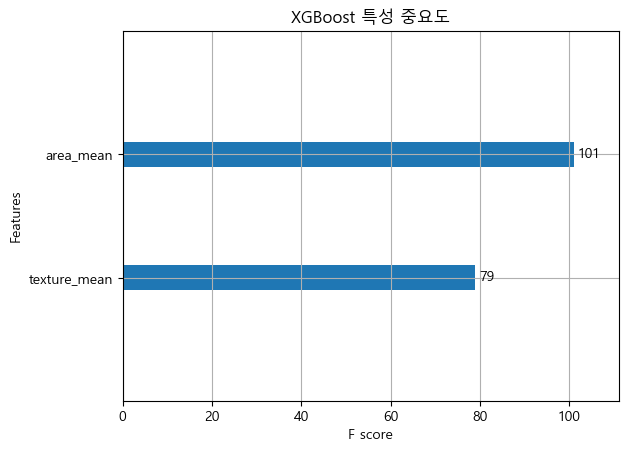

In [16]:
# 특성 중요도
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

plot_importance(xgb, title="XGBoost 특성 중요도")
plt.show()

### (2) 회귀문제

In [17]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

car = pd.read_csv(
    "https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/CarPrice_Assignment.csv"
)
car_num = car.select_dtypes(["number"])

features_reg = list(car_num.columns.difference(["car_ID", "symboling", "price"]))
X = car_num[features_reg]
y = car_num["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [18]:
from xgboost import XGBRegressor

# 앞서 준비한 자동차 데이터 사용 (x_tr, x_te, y_tr, y_te)
xgb_reg = XGBRegressor(
    n_estimators=200, max_depth=5, 
    learning_rate=0.2,random_state=42)

xgb_reg.fit(X_train, y_train)
pred_xgb_r = xgb_reg.predict(X_test)

mse  = mean_squared_error(y_test, pred_xgb_r)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, pred_xgb_r)
print(f"RMSE: {rmse:.1f}, MAE: {mae:.1f}")
print(f"R2(ACC): {xgb_reg.score(X_test, y_test)*100:.3f}%")

[18:07:11] WARNING: C:/Jenkins/workspace/xgboost-win64_release_0.90/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
RMSE: 2249.7, MAE: 1439.2
R2(ACC): 91.617%


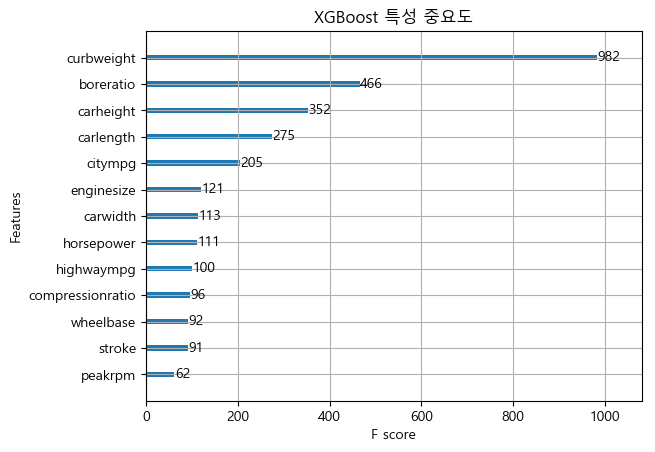

In [19]:
# 특성 중요도
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

plot_importance(xgb_reg, title="XGBoost 특성 중요도")
plt.show()

## 3. LightGBM

### (1) 분류문제

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

breast = pd.read_csv(
    "https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/breast-cancer.csv"
)

# 레이블 이진화: 악성(M)=1, 양성(B)=0
breast["diagnosis"] = np.where(breast["diagnosis"] == "M", 1, 0)
features = ["area_mean", "texture_mean"]
X = breast[features]
y = breast["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=1)

In [2]:
# 1. 현재 커널에 lightgbm 강제 설치
#import sys
#!{sys.executable} -m pip install lightgbm==2.2.3

# 2. 설치 후 'Kernel' -> 'Restart'를 꼭 눌러주세요!

In [3]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(
    n_estimators=200,
    num_leaves=31,
    learning_rate=0.05,
    random_state=42
)

lgbm_clf.fit(X_train, y_train)
pred_lgbm = lgbm_clf.predict(X_test)

In [4]:
from sklearn.metrics import accuracy_score, classification_report

print(classification_report(y_test, pred_lgbm))
print("정확도:", round(accuracy_score(y_test, pred_lgbm)*100, 2), "%")

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       107
           1       0.83      0.78      0.81        64

    accuracy                           0.86       171
   macro avg       0.85      0.84      0.85       171
weighted avg       0.86      0.86      0.86       171

정확도: 85.96 %


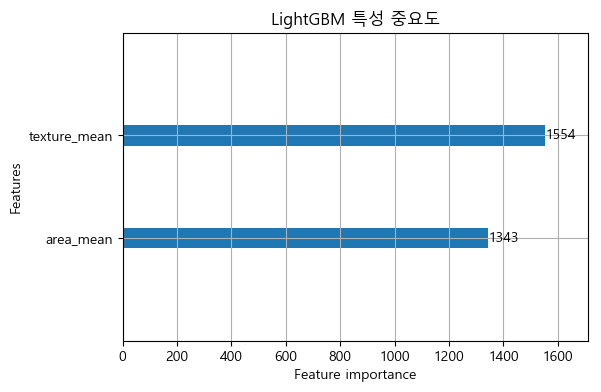

In [5]:
# 특성 중요도
import matplotlib.pyplot as plt
import lightgbm as lgb

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

lgb.plot_importance(lgbm_clf, figsize=(6,4), title="LightGBM 특성 중요도")
plt.show()

### (2) 회귀문제

In [6]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

car = pd.read_csv(
    "https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/CarPrice_Assignment.csv"
)
car_num = car.select_dtypes(["number"])

features_reg = list(car_num.columns.difference(["car_ID", "symboling", "price"]))
X = car_num[features_reg]
y = car_num["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [7]:
from lightgbm import LGBMRegressor

lgbm_reg = LGBMRegressor(
    n_estimators=200, num_leaves=31, learning_rate=0.05,
    subsample=0.8, random_state=42)

lgbm_reg.fit(X_train, y_train)
pred_lgbm_r = lgbm_reg.predict(X_test)

In [8]:
mse  = mean_squared_error(y_test, pred_lgbm_r)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, pred_lgbm_r)
print(f"RMSE: {rmse:.1f}, MAE: {mae:.1f}")
print(f"R2(ACC): {lgbm_reg.score(X_test, y_test)*100:.3f}%")

RMSE: 3060.4, MAE: 1760.8
R2(ACC): 84.486%


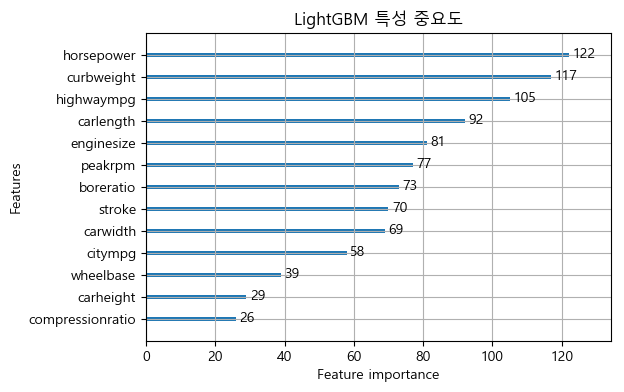

In [9]:
# 특성 중요도
import matplotlib.pyplot as plt
import lightgbm as lgb

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

lgb.plot_importance(lgbm_reg, figsize=(6,4), title="LightGBM 특성 중요도")
plt.show()